In [ ]:
DATA_PATH = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Veri dosyası bulunamadı: {DATA_PATH}\n"
    )

df = pd.read_csv(DATA_PATH)

print("Veri başarıyla yüklendi.")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")

df.head()

Veri başarıyla yüklendi.
Satır sayısı: 7043
Sütun sayısı: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
info_table = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "unique": df.nunique()
}).reset_index().rename(columns={"index": "column"})

info_table.to_csv(TABLE_DIR / "01_data_info.csv", index=False)

info_table

,column,dtype,non_null,missing,unique
0,customerID,str,7043,0,7043
1,gender,str,7043,0,2
2,SeniorCitizen,int64,7043,0,2
3,Partner,str,7043,0,2
4,Dependents,str,7043,0,2
5,tenure,int64,7043,0,73
6,PhoneService,str,7043,0,2
7,MultipleLines,str,7043,0,3
8,InternetService,str,7043,0,3
9,OnlineSecurity,str,7043,0,3


In [4]:
numeric_summary = df.describe().T
numeric_summary.to_csv(TABLE_DIR / "02_numeric_summary.csv")

numeric_summary

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [5]:
categorical_cols_raw = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols_raw:
    print("\n" + "="*60)
    print(col)
    print(df[col].value_counts(dropna=False).head(10))


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Na

In [6]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_total_charges = total_charges_numeric.isna().sum()

print("TotalCharges sayısala çevrildiğinde eksik olan satır sayısı:", missing_total_charges)

if missing_total_charges > 0:
    display(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

TotalCharges sayısala çevrildiğinde eksik olan satır sayısı: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

churn_table = pd.DataFrame({
    "count": churn_counts,
    "percent": churn_percent.round(2)
})

churn_table.to_csv(TABLE_DIR / "03_churn_distribution.csv")

churn_table

,count,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


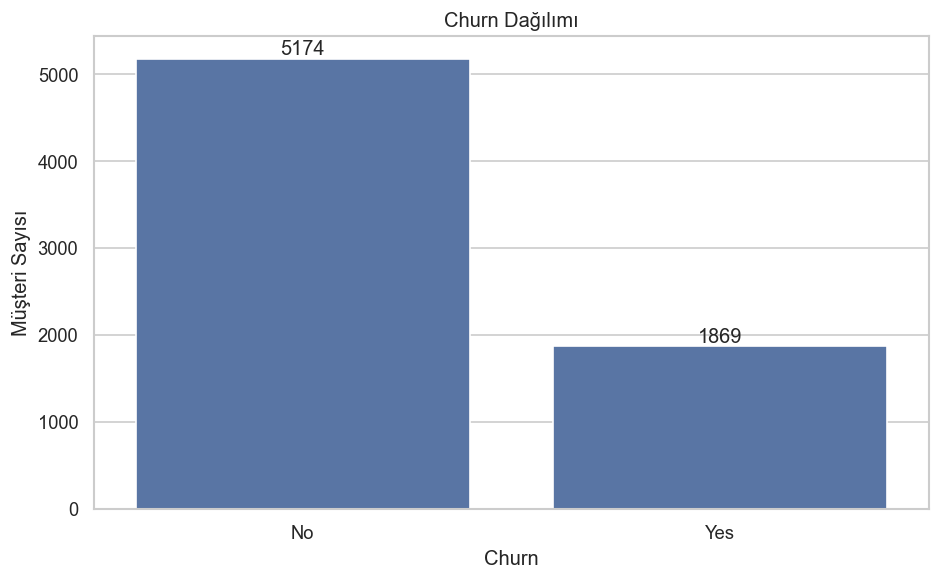

In [8]:
ax = sns.countplot(data=df, x="Churn")
ax.set_title("Churn Dağılımı")
ax.set_xlabel("Churn")
ax.set_ylabel("Müşteri Sayısı")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_churn_distribution.png")
plt.show()

In [9]:
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
df_eda["TotalCharges"] = df_eda["TotalCharges"].fillna(0)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df_eda[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


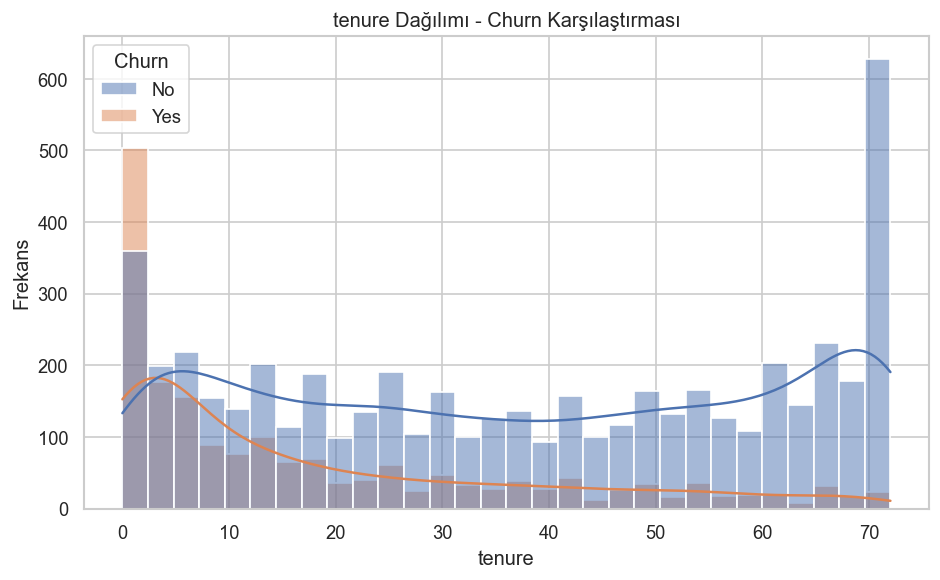

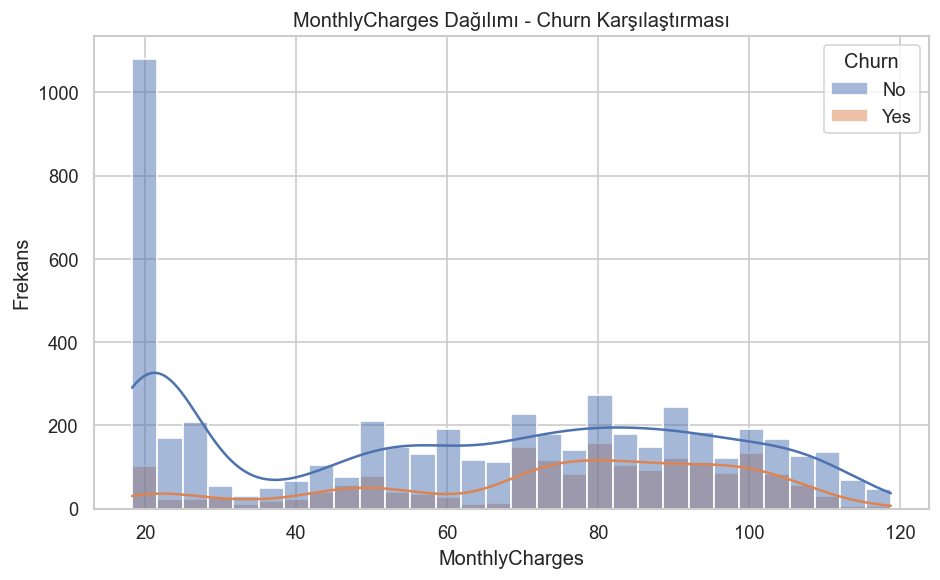

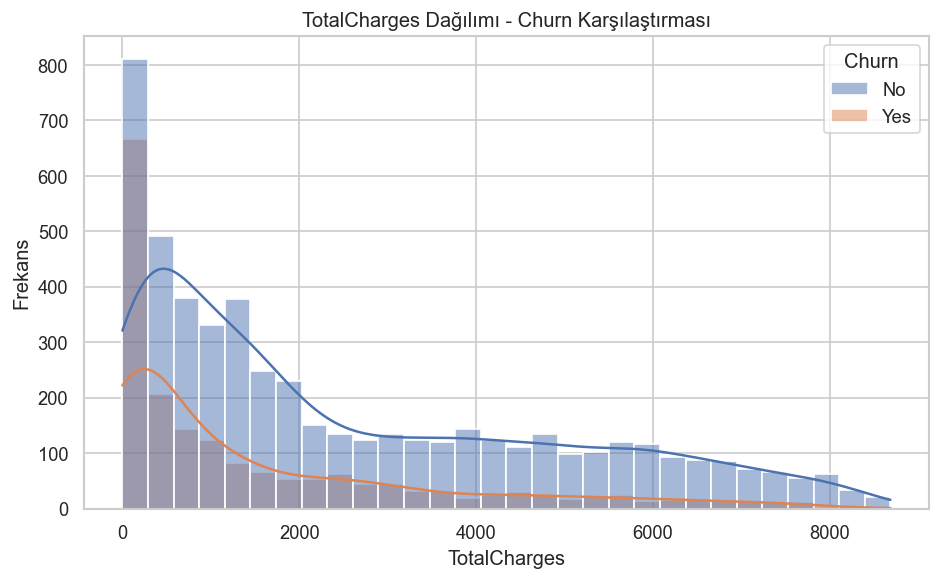

In [10]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df_eda, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"{col} Dağılımı - Churn Karşılaştırması")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"02_hist_{col}.png")
    plt.show()

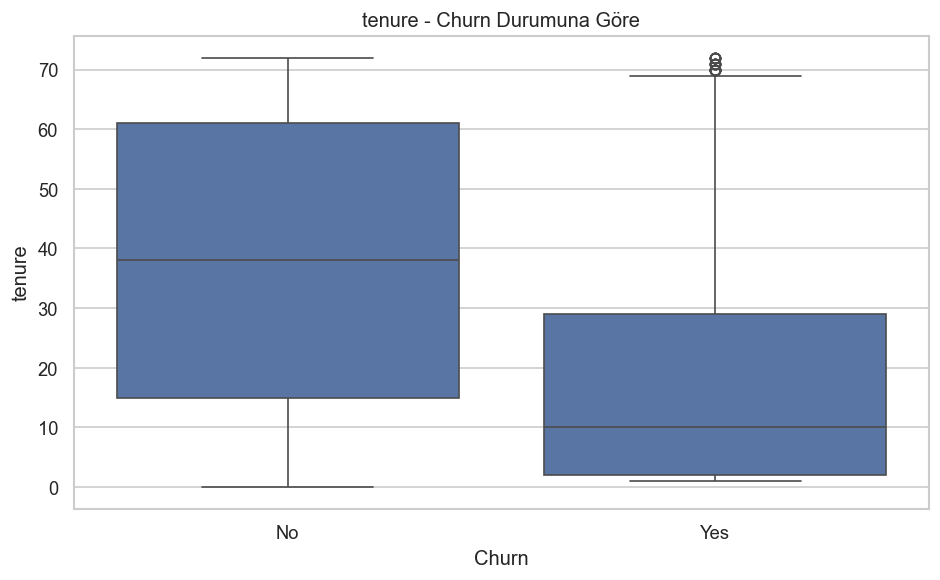

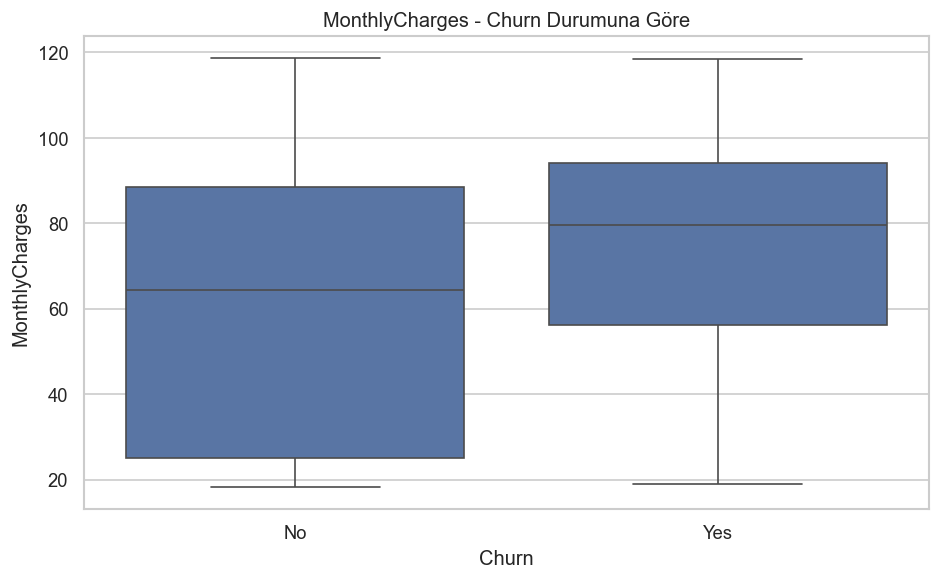

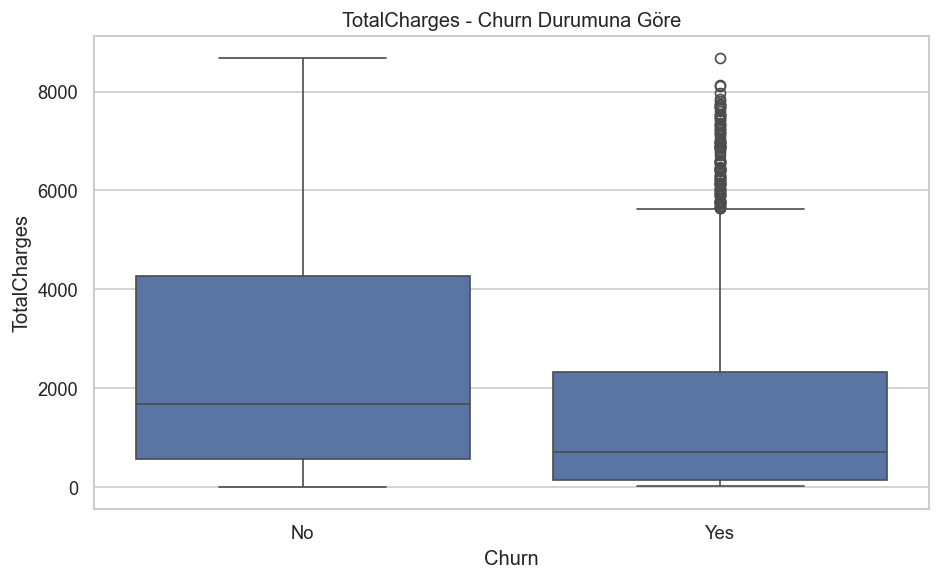

In [11]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df_eda, x="Churn", y=col)
    plt.title(f"{col} - Churn Durumuna Göre")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"03_box_{col}.png")
    plt.show()

In [12]:
def churn_rate_by_category(data, column, target="Churn"):
    temp = data.copy()
    temp[target] = (temp[target] == "Yes").astype(int)

    result = (
        temp.groupby(column)[target]
        .agg(["count", "mean"])
        .rename(columns={"count": "n_customers", "mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )

    result["churn_rate_percent"] = (result["churn_rate"] * 100).round(2)
    return result


important_categorical_cols = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for col in important_categorical_cols:
    print("\n" + "="*70)
    print(col)
    result = churn_rate_by_category(df_eda, col)
    result.to_csv(TABLE_DIR / f"04_churn_rate_{col}.csv")
    display(result)


Contract


,n_customers,churn_rate,churn_rate_percent
Contract,,,
Month-to-month,3875,0.427097,42.71
One year,1473,0.112695,11.27
Two year,1695,0.028319,2.83



InternetService


,n_customers,churn_rate,churn_rate_percent
InternetService,,,
Fiber optic,3096,0.418928,41.89
DSL,2421,0.189591,18.96
No,1526,0.074050,7.40



OnlineSecurity


...

,n_customers,churn_rate,churn_rate_percent
SeniorCitizen,,,
1,1142,0.416813,41.68
0,5901,0.236062,23.61



Partner


,n_customers,churn_rate,churn_rate_percent
Partner,,,
No,3641,0.329580,32.96
Yes,3402,0.196649,19.66



Dependents


,n_customers,churn_rate,churn_rate_percent
Dependents,,,
No,4933,0.312791,31.28
Yes,2110,0.154502,15.45


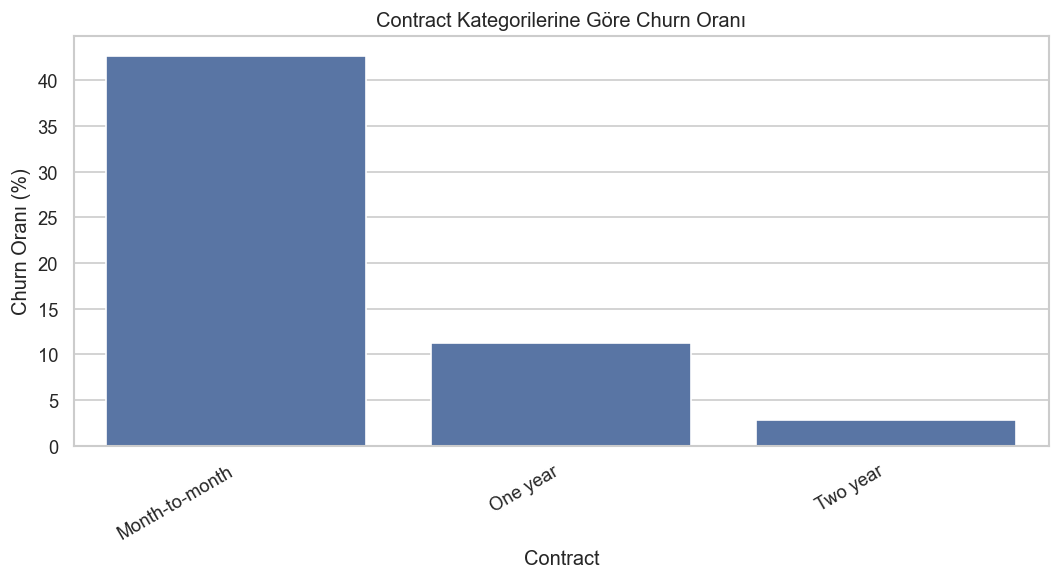

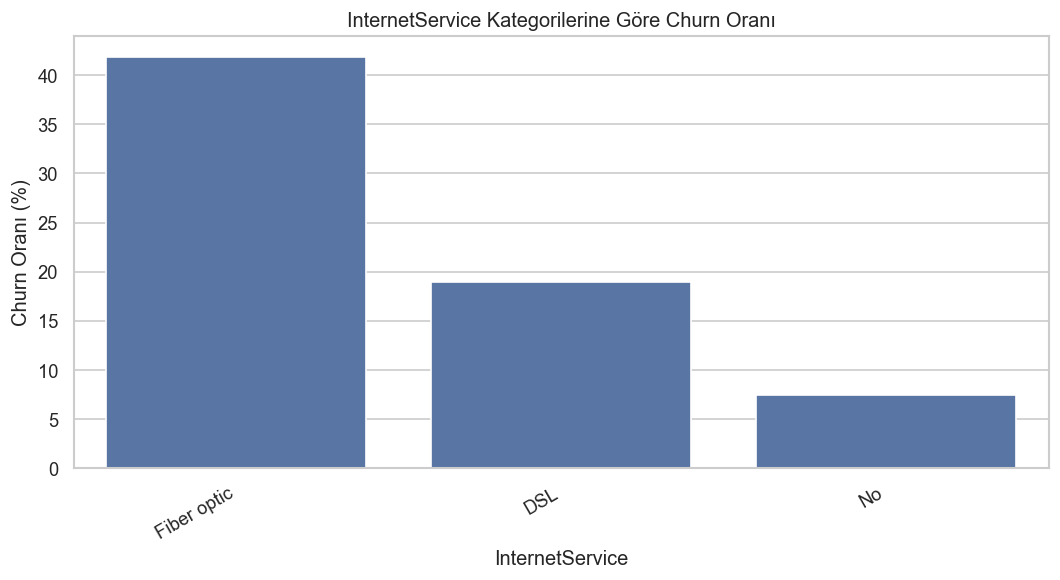

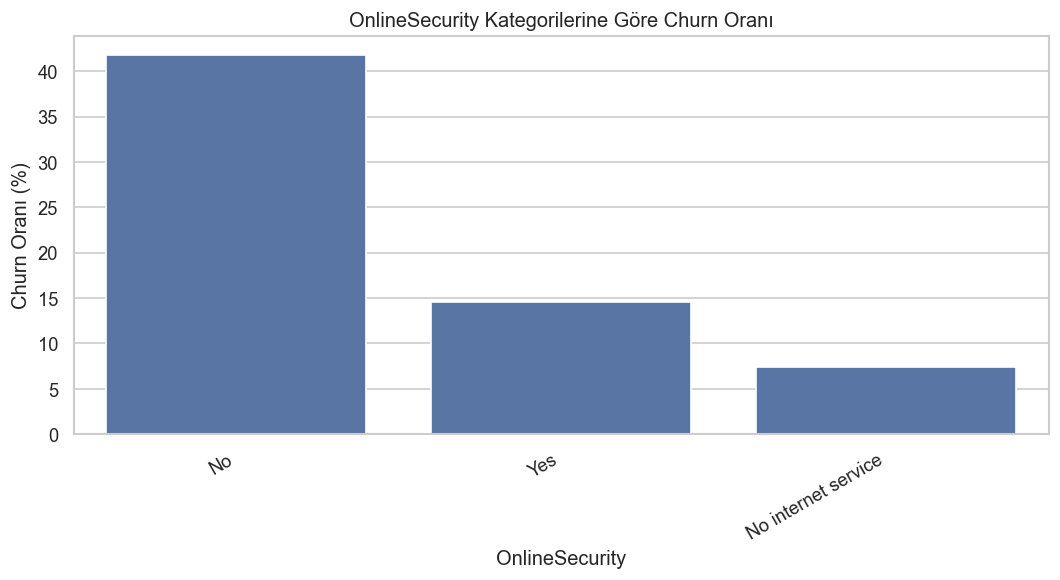

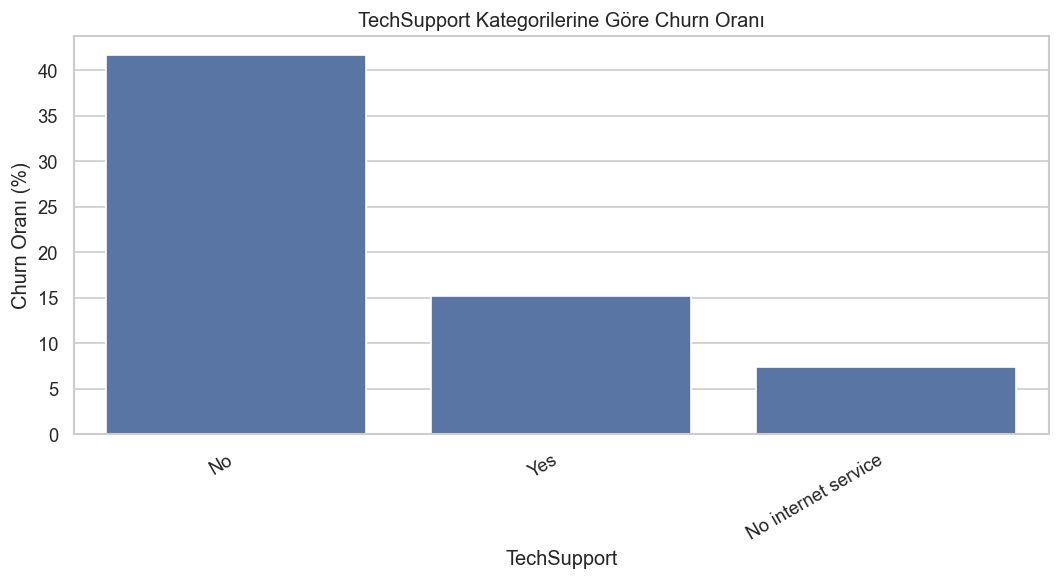

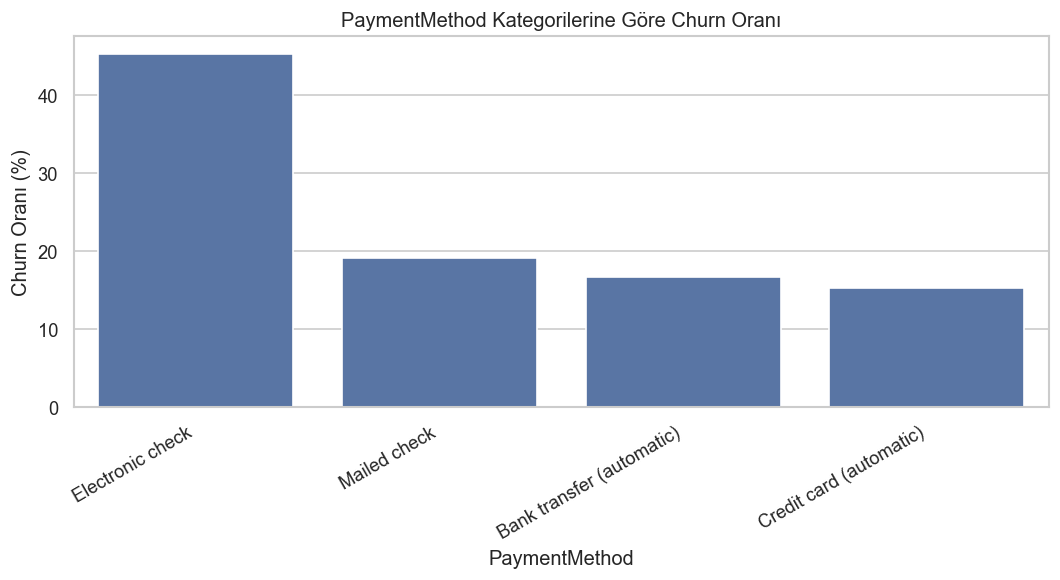

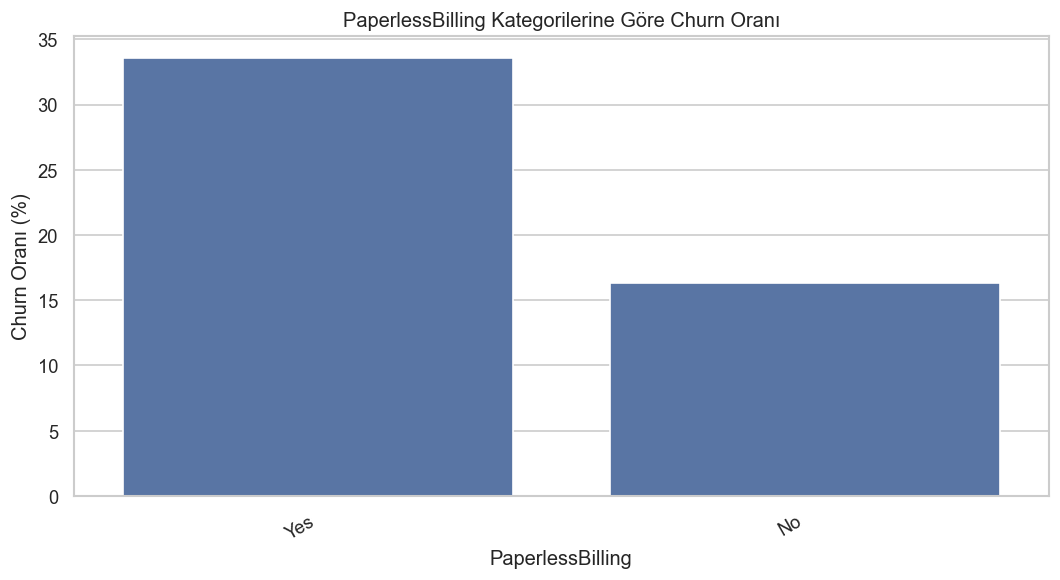

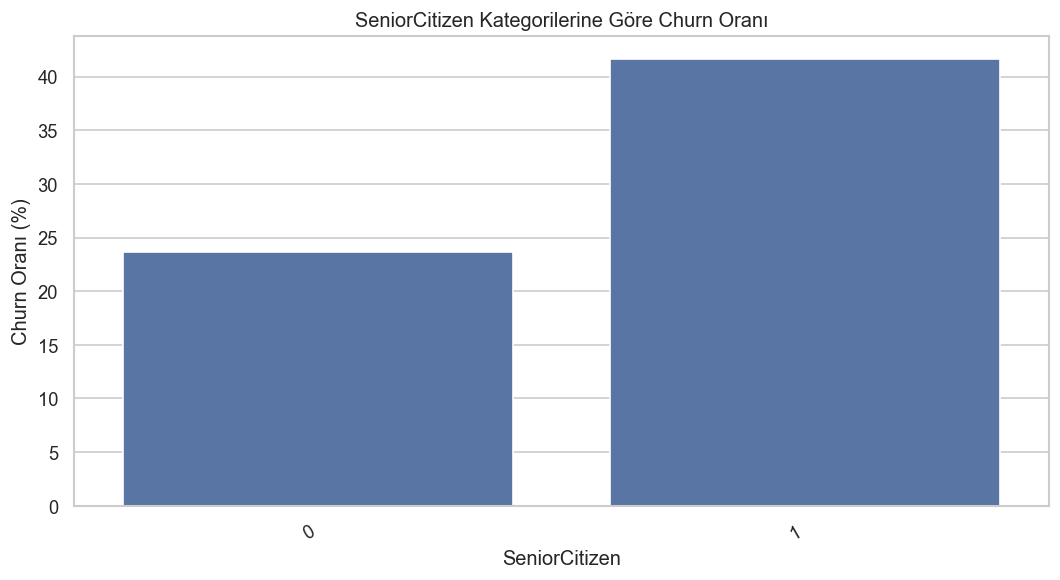

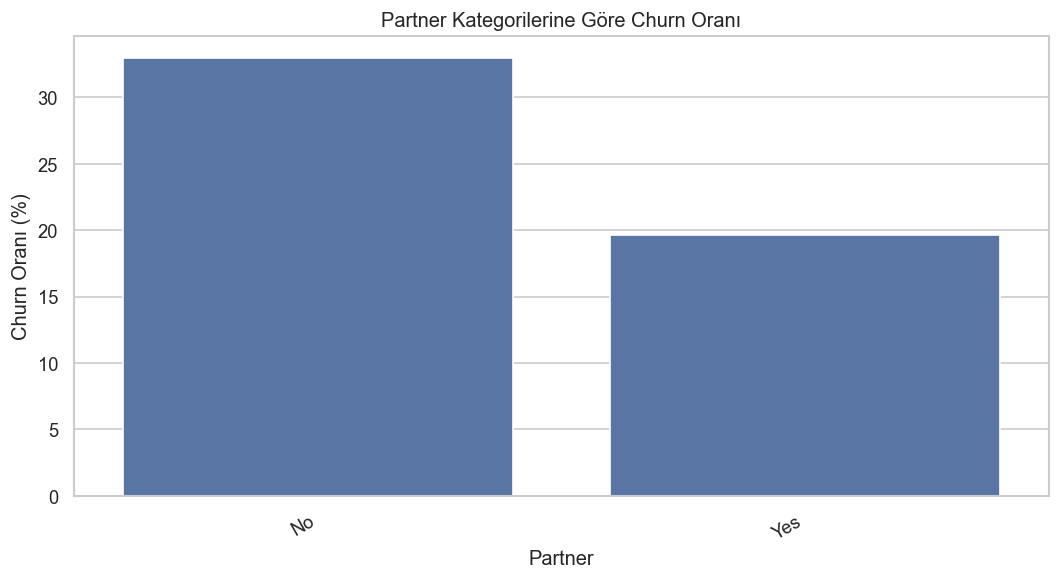

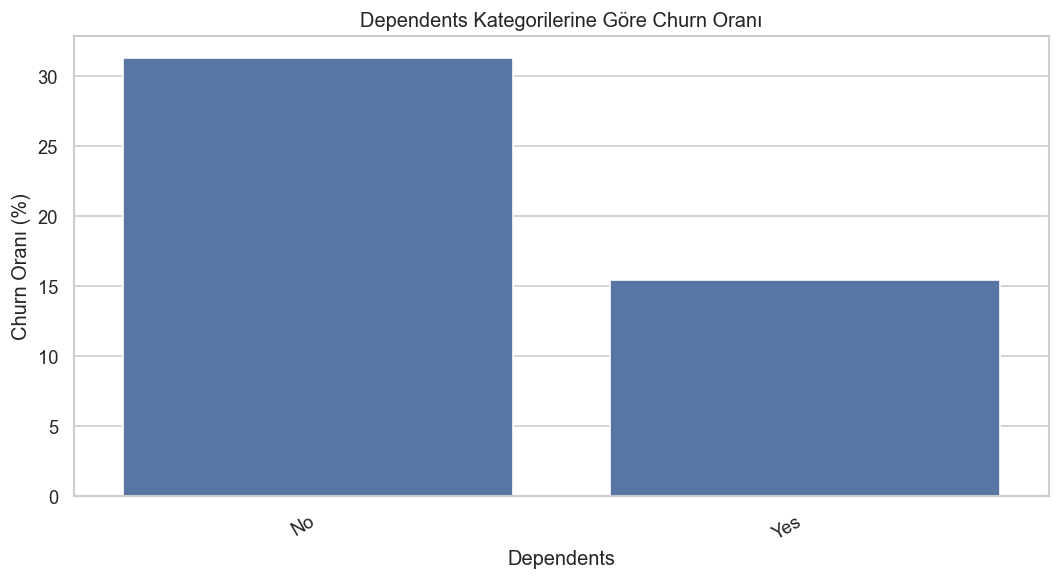

In [13]:
for col in important_categorical_cols:
    rate_table = churn_rate_by_category(df_eda, col).reset_index()

    plt.figure(figsize=(9, 5))
    sns.barplot(data=rate_table, x=col, y="churn_rate_percent")
    plt.title(f"{col} Kategorilerine Göre Churn Oranı")
    plt.xlabel(col)
    plt.ylabel("Churn Oranı (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"04_churn_rate_{col}.png")
    plt.show()